In [4]:
import numpy as np
import glob
import re

from aicsimageio import AICSImage, readers
from pathlib import Path
from matplotlib import pyplot as plt

from blimp.preprocessing.illumination_correction import IlluminationCorrection

# Correct illumination

Search images of the correct channel in the input directories

In [5]:
images_dir = Path("/srv/scratch/berrylab/z3532965/systems_Ti2/20260626_POLR2A_heterogeneity/20260629_134305_894/OME-TIFF-MIP")
image_files = glob.glob(str(images_dir / "*.tiff"))

In [6]:
len(image_files)

1296

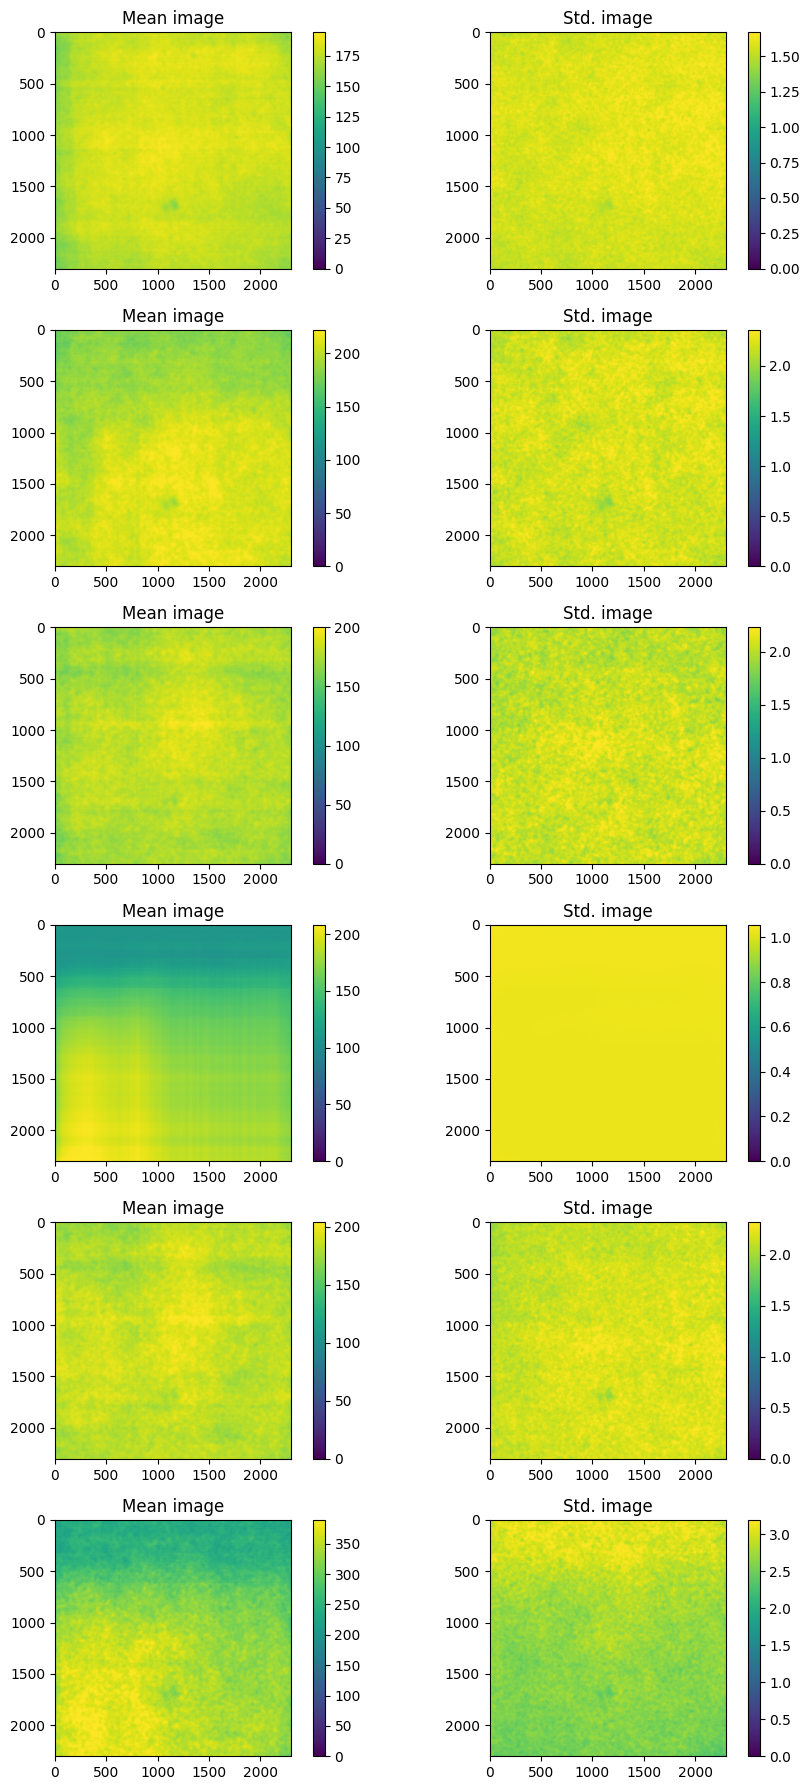

In [7]:
illumination_correction = IlluminationCorrection(
    reference_images=image_files,
    timelapse=False,
)
illumination_correction.plot()

# Save illumination correction object to disk

The ``blimp.IlluminationCorrection`` object can be persisted on disk to be later applied when analysing images

In [8]:
illumcorr_filename = "/srv/scratch/berrylab/z3532965/systems_Ti2/20260626_POLR2A_heterogeneity/20260629_134305_894/illumination_correction.pkl"

In [9]:
illumination_correction.save(Path(illumcorr_filename))

# Check results

IlluminationCorrection can be applied using the ``correct()`` method of the ``blimp.IlluminationCorrection`` object

In [10]:
illumination_correction = IlluminationCorrection(from_file=illumcorr_filename)

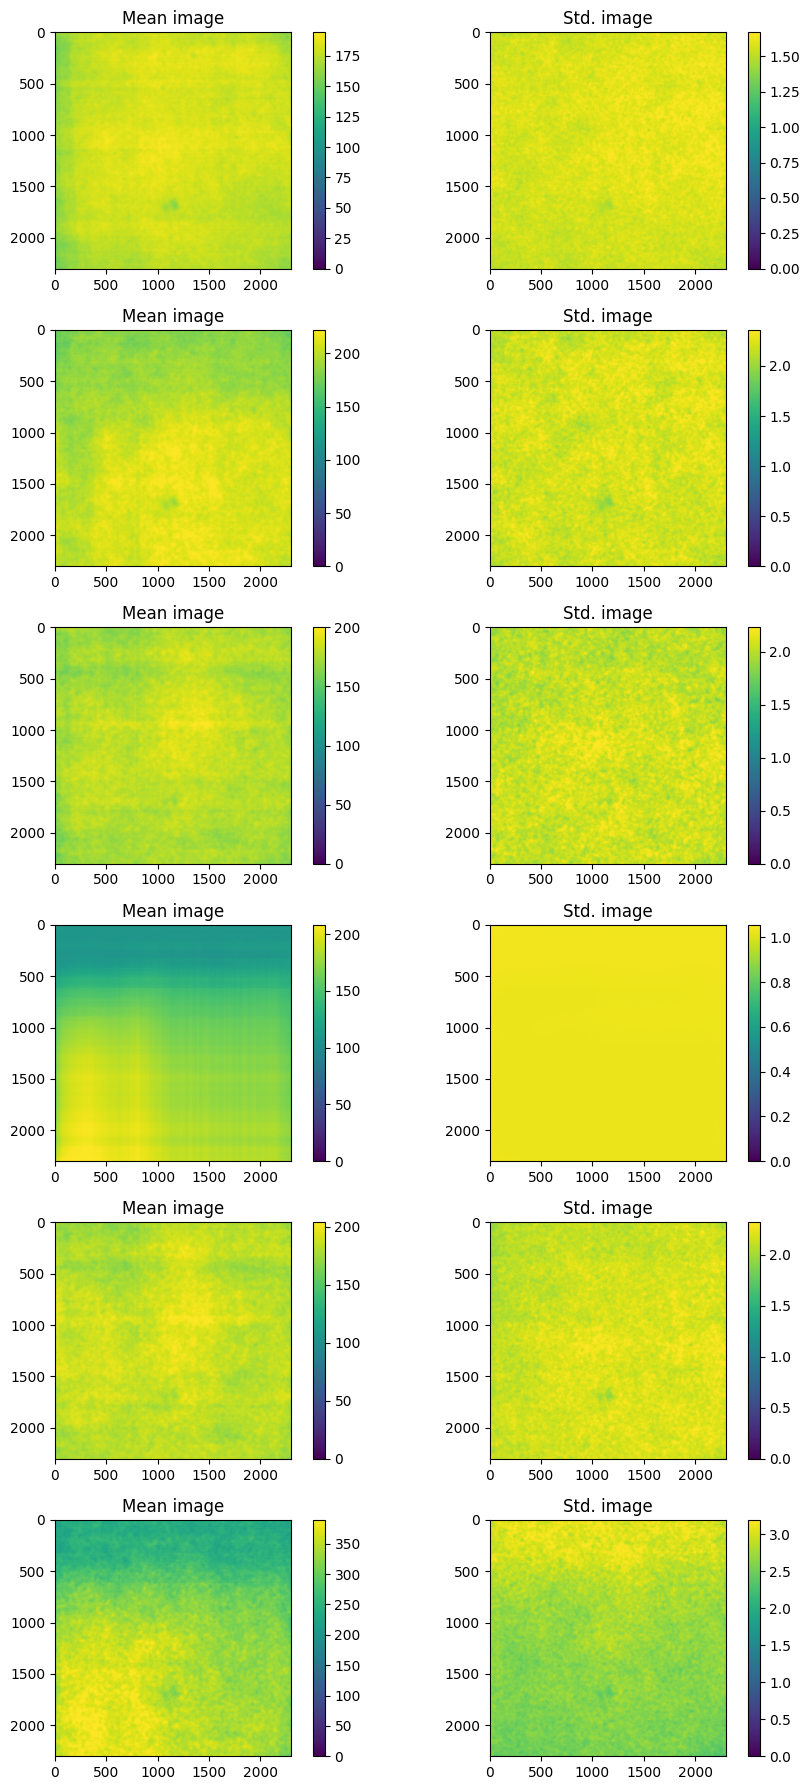

In [11]:
illumination_correction.plot()

In [12]:
raw = AICSImage(image_files[102], reader=readers.ome_tiff_reader.OmeTiffReader)
corrected = illumination_correction.correct(raw)

In [13]:
#illumination_correction.mean_image.get_image_data("YX", C=1, Z=0, T=0)
illumination_correction.mean_mean_image

[2.252209087517075,
 2.3022555361002675,
 2.2497306059405844,
 2.1970053112221346,
 2.2670242494593587,
 2.4982649880010843]

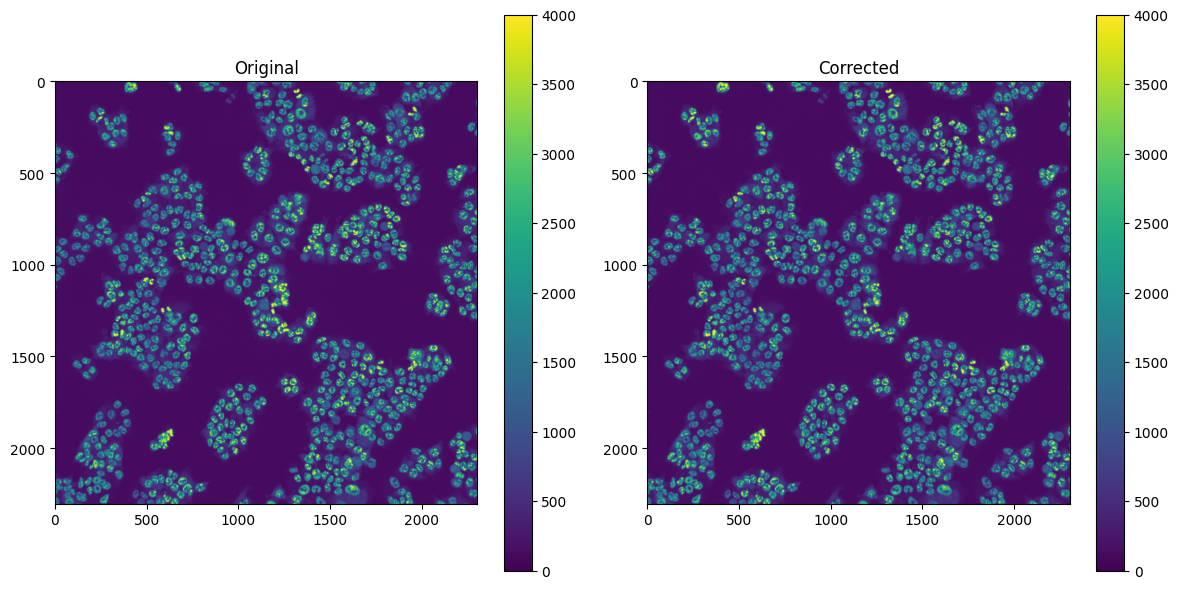

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
im = axes[0].imshow(raw.get_image_data('YX',C=4,T=0), vmin=0, vmax=4000)
fig.colorbar(im, ax=axes[0])
axes[0].set_title("Original")
im = axes[1].imshow(corrected.get_image_data('YX',C=4,T=0), vmin=0, vmax=4000)
fig.colorbar(im, ax=axes[1])
axes[1].set_title("Corrected")
fig.tight_layout()

In [18]:
corrected.channel_names

['None', '488', '561', 'XXX', '647', '405']